In [14]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, util

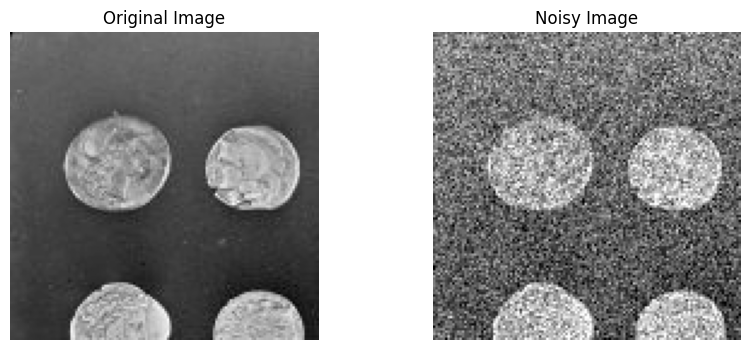

In [25]:
# Load image
# image = color.rgb2gray(data.astronaut())
image = data.coins()
# Resize
image = image[0:128, 0:128]

# Add Gaussian noise
noisy = util.random_noise(image, mode='gaussian', var=0.02)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.axis('off')

plt.show()

In [26]:
# Parameters
beta = 1.0
iterations = 10

# Convert to binary image
noisy_bin = (noisy > 0.5).astype(int)
denoised = noisy_bin.copy()

rows, cols = denoised.shape

In [27]:
# Gibbs Sampling with MRF

for it in range(iterations):

    for i in range(rows):
        for j in range(cols):

            neighbors = []

            if i > 0:
                neighbors.append(denoised[i-1, j])

            if i < rows-1:
                neighbors.append(denoised[i+1, j])

            if j > 0:
                neighbors.append(denoised[i, j-1])

            if j < cols-1:
                neighbors.append(denoised[i, j+1])

            # Unary potential
            unary_0 = (noisy_bin[i,j] - 0)**2
            unary_1 = (noisy_bin[i,j] - 1)**2

            # Pairwise potential
            pair_0 = beta * sum([n != 0 for n in neighbors])
            pair_1 = beta * sum([n != 1 for n in neighbors])

            # Total energy
            energy0 = unary_0 + pair_0
            energy1 = unary_1 + pair_1

            denoised[i,j] = 0 if energy0 < energy1 else 1

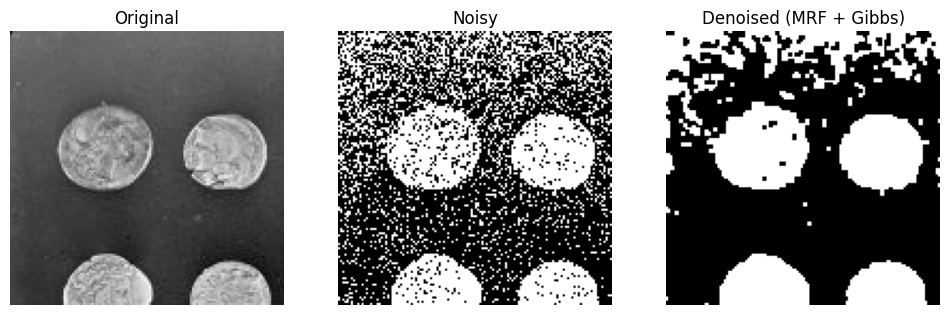

In [28]:
# Visualization
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(noisy_bin, cmap='gray')
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised (MRF + Gibbs)")
plt.axis('off')

plt.show()